# A4 - Dataset 2: Diabetes Health Indicators

- **Dạng dữ liệu:** tabular.
- **Task:** binary classification.
- **CNN:** Conv1D trên chuỗi feature (teaching experiment).
- **Basic CNN:** `Conv1D -> ReLU -> Conv1D -> ReLU -> MaxPool1D -> Flatten -> Dense(1)`
- **Cải tiến quan trọng:** xử lý **class imbalance** bằng weighted loss/class weight.
- **Metrics:** Accuracy, Precision, Recall, F1, Loss vs Epoch.


> **Phạm vi A4 notebook này bao phủ:** Load dataset → Basic/Discover CNN → Improved CNN → CNN From Scratch → PyTorch → TensorFlow → Train/Evaluate/Compare.
>
> **Lưu ý:** bảng giao bài không quy định cụ thể “Improved CNN” phải dùng kỹ thuật nào. Trong notebook này, bản Improved dùng thêm filters/layer và BatchNorm/Dropout ở framework như một phương án cải tiến hợp lý; phần From Scratch tập trung đúng mục tiêu bài giảng là tự cài convolution, forward/backprop và cập nhật tham số.
>
> Notebook đặt trong `ASignment4/notebooks/`; dữ liệu ở `../data/`, model ở `../models/`, kết quả ở `../results/`.

In [1]:
from pathlib import Path
import random, warnings, re
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

SEED=42
random.seed(SEED)
np.random.seed(SEED)

ROOT=Path("..")
DATA_DIR=ROOT/"data"
MODEL_DIR=ROOT/"models"
RESULT_DIR=ROOT/"results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

TRAIN_LIMIT=None

## 1. Load, xác định target, split và chuẩn hóa

In [2]:
df = pd.read_csv(DATA_DIR/"diabete.csv")
print("Shape:", df.shape)
display(df.head())

def norm_name(s):
    return re.sub(r"[^a-z0-9]","",str(s).lower())

norm_map={norm_name(c):c for c in df.columns}
target_col = norm_map.get("diabetesbinary")
if target_col is None:
    hits=[c for c in df.columns if "diabetes" in c.lower()]
    if len(hits) != 1:
        raise ValueError(f"Không xác định được target: {hits}")
    target_col=hits[0]

print("Target:", target_col)
print(df[target_col].value_counts().sort_index())

Shape: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Target: Diabetes_binary
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64


In [3]:
X_df=df.drop(columns=[target_col]).apply(pd.to_numeric, errors="coerce")
X_df=X_df.fillna(X_df.median(numeric_only=True))
y_raw=pd.to_numeric(df[target_col], errors="coerce").fillna(0)

if set(y_raw.unique()).issubset({0,1}):
    y=y_raw.astype(np.int64).to_numpy()
else:
    y=(y_raw>0).astype(np.int64).to_numpy()

X_train_df,X_test_df,y_train,y_test=train_test_split(
    X_df,y,test_size=0.2,random_state=SEED,stratify=y
)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train_df).astype(np.float32)
X_test=scaler.transform(X_test_df).astype(np.float32)

X_train_ncl=X_train[:,None,:]
X_test_ncl=X_test[:,None,:]

n0=(y_train==0).sum()
n1=(y_train==1).sum()
POS_WEIGHT=float(n0/n1)

print("Train:",X_train_ncl.shape)
print("Test :",X_test_ncl.shape)
print("Class 0:",n0,"Class 1:",n1,"POS_WEIGHT:",POS_WEIGHT)

Train: (202944, 1, 21)
Test : (50736, 1, 21)
Class 0: 174667 Class 1: 28277 POS_WEIGHT: 6.176998974431517


## 2. CNN From Scratch + weighted BCE

Bản trước đạt Accuracy cao nhưng F1 gần 0 vì dữ liệu lệch lớp.  
Bản này dùng **weighted Binary Cross Entropy**, tăng trọng số lỗi của lớp dương để model không chỉ đoán lớp 0.

In [4]:
from numpy.lib.stride_tricks import sliding_window_view

def take_limit(X,y,limit):
    if limit is None or limit>=len(X):
        return X,y
    return X[:limit],y[:limit]

X_fit,y_fit=take_limit(X_train_ncl,y_train,TRAIN_LIMIT)

class Conv1DSameManual:
    def __init__(self,in_channels,out_channels,kernel_size=3,seed=42):
        rng=np.random.default_rng(seed)
        self.k=kernel_size
        self.pad=kernel_size//2
        self.W=(rng.standard_normal((out_channels,in_channels,kernel_size))
                *np.sqrt(2/(in_channels*kernel_size))).astype(np.float32)
        self.b=np.zeros(out_channels,dtype=np.float32)

    def forward(self,x):
        self.x=x
        p=self.pad
        self.xp=np.pad(x,((0,0),(0,0),(p,p)),mode="constant")
        windows=sliding_window_view(self.xp,self.k,axis=2)
        return np.einsum("nclk,fck->nfl",windows,self.W)+self.b[None,:,None]

    def backward(self,dout,lr):
        windows=sliding_window_view(self.xp,self.k,axis=2)
        dW=np.einsum("nfl,nclk->fck",dout,windows)
        db=dout.sum(axis=(0,2))
        dxp=np.zeros_like(self.xp)
        L=dout.shape[2]
        for j in range(self.k):
            dxp[:,:,j:j+L]+=np.einsum("nfl,fc->ncl",dout,self.W[:,:,j])
        p=self.pad
        dx=dxp[:,:,p:-p] if p>0 else dxp
        self.W-=lr*dW
        self.b-=lr*db
        return dx

class DenseManual:
    def __init__(self,in_dim,out_dim=1,seed=42):
        rng=np.random.default_rng(seed)
        self.W=(rng.standard_normal((in_dim,out_dim))*np.sqrt(2/in_dim)).astype(np.float32)
        self.b=np.zeros(out_dim,dtype=np.float32)
    def forward(self,x):
        self.x=x
        return x@self.W+self.b
    def backward(self,dout,lr):
        dx=dout@self.W.T
        self.W-=lr*(self.x.T@dout)
        self.b-=lr*dout.sum(axis=0)
        return dx

def sigmoid(x):
    x=np.clip(x,-30,30)
    return 1/(1+np.exp(-x))

def weighted_bce_logits(logits,y,pos_weight):
    p=sigmoid(logits)
    n=len(y)
    w=1+(pos_weight-1)*y
    loss=-np.mean(pos_weight*y*np.log(p+1e-12)+(1-y)*np.log(1-p+1e-12))
    d=((p-y)*w/n)[:,None]
    return float(loss),d


class MaxPool1DManual:
    def forward(self, x):
        self.x = x
        N, C, L = x.shape
        L2 = L // 2
        x_crop = x[:, :, :L2*2]
        xr = x_crop.reshape(N, C, L2, 2)
        self.maxv = xr.max(axis=3, keepdims=True)
        self.crop_shape = x_crop.shape
        return self.maxv.squeeze(3)

    def backward(self, dout):
        x = self.x
        N, C, L = x.shape
        L2 = L // 2
        x_crop = x[:, :, :L2*2]
        xr = x_crop.reshape(N, C, L2, 2)
        mask = xr == self.maxv
        denom = mask.sum(axis=3, keepdims=True)
        dxr = mask * (dout[:, :, :, None] / denom)
        dx = np.zeros_like(x)
        dx[:, :, :L2*2] = dxr.reshape(self.crop_shape)
        return dx

class ManualDiabetesCNN:
    def __init__(self,L,seed=42):
        self.conv1=Conv1DSameManual(1,8,3,seed)
        self.conv2=Conv1DSameManual(8,8,3,seed+1)
        self.pool=MaxPool1DManual()
        self.fc=DenseManual(8*(L//2),1,seed+2)

    def forward(self,x):
        self.z1=self.conv1.forward(x)
        self.h1=np.maximum(self.z1,0)
        self.z2=self.conv2.forward(self.h1)
        self.h2=np.maximum(self.z2,0)
        self.p=self.pool.forward(self.h2)
        self.pool_shape=self.p.shape
        return self.fc.forward(self.p.reshape(len(x),-1)).ravel()

    def train_batch(self,x,y,lr,pos_weight):
        logits=self.forward(x)
        loss,dlogit=weighted_bce_logits(logits,y,pos_weight)
        dp=self.fc.backward(dlogit,lr).reshape(self.pool_shape)
        dh2=self.pool.backward(dp)
        dz2=dh2*(self.z2>0)
        dh1=self.conv2.backward(dz2,lr)
        dz1=dh1*(self.z1>0)
        self.conv1.backward(dz1,lr)
        return loss

    def predict_proba(self,X,batch_size=1024):
        ps=[]
        for s in range(0,len(X),batch_size):
            ps.append(sigmoid(self.forward(X[s:s+batch_size])))
        return np.concatenate(ps)

def train_manual(model,X,y,epochs=8,batch_size=512,lr=0.003):
    rng=np.random.default_rng(SEED)
    hist=[]
    for ep in range(epochs):
        order=rng.permutation(len(X))
        ls=[]
        for s in range(0,len(X),batch_size):
            b=order[s:s+batch_size]
            ls.append(model.train_batch(X[b],y[b],lr,POS_WEIGHT))
        hist.append(float(np.mean(ls)))
        print(f"Epoch {ep+1}/{epochs} - loss={hist[-1]:.4f}")
    return hist

In [5]:
manual=ManualDiabetesCNN(X_train_ncl.shape[2],SEED)
scratch_loss=train_manual(manual,X_fit,y_fit,epochs=8,batch_size=512,lr=0.003)

scratch_prob=manual.predict_proba(X_test_ncl)
scratch_pred=(scratch_prob>=0.5).astype(int)

scratch_acc=accuracy_score(y_test,scratch_pred)
scratch_p,scratch_r,scratch_f1,_=precision_recall_fscore_support(
    y_test,scratch_pred,average="binary",zero_division=0
)

print(f"Scratch Acc={scratch_acc:.4f} | P={scratch_p:.4f} | R={scratch_r:.4f} | F1={scratch_f1:.4f}")

np.savez(
    MODEL_DIR/"diabetes_scratch_fixed.npz",
    conv1_W=manual.conv1.W,conv1_b=manual.conv1.b,
    conv2_W=manual.conv2.W,conv2_b=manual.conv2.b,
    fc_W=manual.fc.W,fc_b=manual.fc.b
)

Epoch 1/8 - loss=1.1116
Epoch 2/8 - loss=0.9842
Epoch 3/8 - loss=0.9467
Epoch 4/8 - loss=0.9283
Epoch 5/8 - loss=0.9184
Epoch 6/8 - loss=0.9128
Epoch 7/8 - loss=0.9088
Epoch 8/8 - loss=0.9059
Scratch Acc=0.7326 | P=0.3082 | R=0.7389 | F1=0.4350


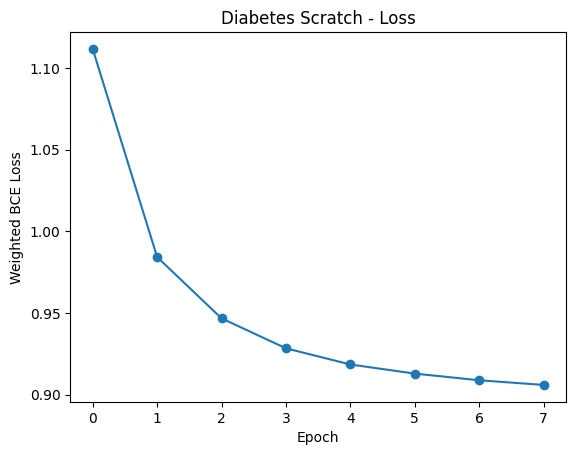

In [6]:
plt.plot(scratch_loss, marker="o")
plt.xlabel("Epoch");plt.ylabel("Weighted BCE Loss")
plt.title("Diabetes Scratch - Loss")
plt.show()

## 3. PyTorch - weighted BCE

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset,DataLoader

torch.manual_seed(SEED)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

Xpt,ypt=take_limit(X_train_ncl,y_train,TRAIN_LIMIT)
tr_loader=DataLoader(
    TensorDataset(torch.tensor(Xpt,dtype=torch.float32),
                  torch.tensor(ypt,dtype=torch.float32)),
    batch_size=512,shuffle=True
)
te_loader=DataLoader(
    TensorDataset(torch.tensor(X_test_ncl,dtype=torch.float32),
                  torch.tensor(y_test,dtype=torch.float32)),
    batch_size=1024,shuffle=False
)

L=X_train_ncl.shape[2]

class TorchBasic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv1d(1,8,3,padding=1),nn.ReLU(),
            nn.Conv1d(8,8,3,padding=1),nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Flatten(),
            nn.Linear(8*(L//2),1)
        )
    def forward(self,x):
        return self.net(x).squeeze(1)

class TorchImproved(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv1d(1,16,3,padding=1),
            nn.BatchNorm1d(16),nn.ReLU(),
            nn.Conv1d(16,32,3,padding=1),
            nn.BatchNorm1d(32),nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(32,1)
        )
    def forward(self,x):
        return self.net(x).squeeze(1)

def train_pt(model,epochs=8):
    model=model.to(device)
    pos=torch.tensor([POS_WEIGHT],dtype=torch.float32,device=device)
    loss_fn=nn.BCEWithLogitsLoss(pos_weight=pos)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)
    hist=[]

    for ep in range(epochs):
        model.train();ls=[]
        for xb,yb in tr_loader:
            xb,yb=xb.to(device),yb.to(device)
            opt.zero_grad()
            logits=model(xb)
            loss=loss_fn(logits,yb)
            loss.backward()
            opt.step()
            ls.append(loss.item())
        hist.append(float(np.mean(ls)))
        print(f"Epoch {ep+1}/{epochs} - loss={hist[-1]:.4f}")
    return model,hist

def eval_pt(model):
    model.eval();probs=[]
    with torch.no_grad():
        for xb,_ in te_loader:
            probs.append(torch.sigmoid(model(xb.to(device))).cpu().numpy())
    pprob=np.concatenate(probs)
    pred=(pprob>=0.5).astype(int)
    acc=accuracy_score(y_test,pred)
    p,r,f1,_=precision_recall_fscore_support(
        y_test,pred,average="binary",zero_division=0
    )
    return pred,acc,p,r,f1

In [8]:
pt_basic,pt_basic_loss=train_pt(TorchBasic(),8)
_,pt_basic_acc,pt_basic_p,pt_basic_r,pt_basic_f1=eval_pt(pt_basic)

pt_imp,pt_imp_loss=train_pt(TorchImproved(),8)
_,pt_imp_acc,pt_imp_p,pt_imp_r,pt_imp_f1=eval_pt(pt_imp)

print("PyTorch Basic   :",pt_basic_acc,pt_basic_p,pt_basic_r,pt_basic_f1)
print("PyTorch Improved:",pt_imp_acc,pt_imp_p,pt_imp_r,pt_imp_f1)

torch.save(pt_basic.state_dict(),MODEL_DIR/"diabetes_pytorch_basic_fixed.pth")
torch.save(pt_imp.state_dict(),MODEL_DIR/"diabetes_pytorch_improved_fixed.pth")

Epoch 1/8 - loss=0.9752
Epoch 2/8 - loss=0.8877
Epoch 3/8 - loss=0.8781
Epoch 4/8 - loss=0.8750
Epoch 5/8 - loss=0.8730
Epoch 6/8 - loss=0.8727
Epoch 7/8 - loss=0.8719
Epoch 8/8 - loss=0.8712
Epoch 1/8 - loss=1.0159
Epoch 2/8 - loss=0.9543
Epoch 3/8 - loss=0.9427
Epoch 4/8 - loss=0.9374
Epoch 5/8 - loss=0.9290
Epoch 6/8 - loss=0.9263
Epoch 7/8 - loss=0.9237
Epoch 8/8 - loss=0.9198
PyTorch Basic   : 0.709575055187638 0.2979867186676505 0.7998302447305136 0.43420496870560227
PyTorch Improved: 0.7529564806054873 0.3219289670902574 0.6988258593860518 0.440795931114482


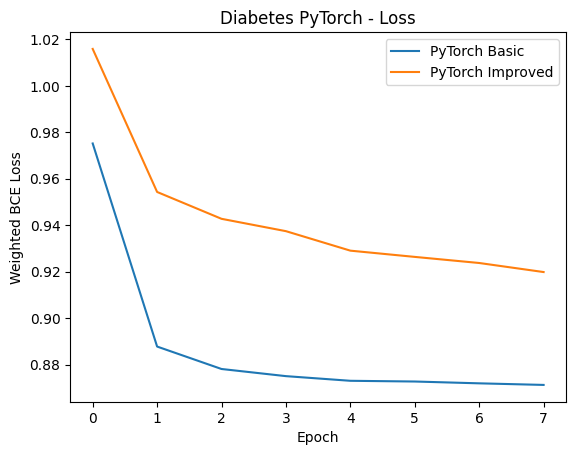

In [9]:
plt.plot(pt_basic_loss,label="PyTorch Basic")
plt.plot(pt_imp_loss,label="PyTorch Improved")
plt.xlabel("Epoch");plt.ylabel("Weighted BCE Loss")
plt.title("Diabetes PyTorch - Loss")
plt.legend();plt.show()

## 4. TensorFlow/Keras - class_weight

In [10]:
import tensorflow as tf
tf.random.set_seed(SEED)

Xtf=np.transpose(Xpt,(0,2,1))
Xtest_tf=np.transpose(X_test_ncl,(0,2,1))

def tf_basic_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input((L,1)),
        tf.keras.layers.Conv1D(8,3,padding="same",activation="relu"),
        tf.keras.layers.Conv1D(8,3,padding="same",activation="relu"),
        tf.keras.layers.MaxPooling1D(2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1,activation="sigmoid")
    ])

def tf_improved_model():
    return tf.keras.Sequential([
        tf.keras.layers.Input((L,1)),
        tf.keras.layers.Conv1D(16,3,padding="same"),
        tf.keras.layers.BatchNormalization(),tf.keras.layers.ReLU(),
        tf.keras.layers.Conv1D(32,3,padding="same"),
        tf.keras.layers.BatchNormalization(),tf.keras.layers.ReLU(),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(1,activation="sigmoid")
    ])

def train_tf(model,epochs=8):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    h=model.fit(
        Xtf,ypt,validation_split=0.1,
        epochs=epochs,batch_size=512,verbose=2,
        class_weight={0:1.0,1:POS_WEIGHT}
    )
    return model,h

In [11]:
tf_basic,tf_basic_hist=train_tf(tf_basic_model(),8)
tf_imp,tf_imp_hist=train_tf(tf_improved_model(),8)

tf_basic_pred=(tf_basic.predict(Xtest_tf,verbose=0).ravel()>=0.5).astype(int)
tf_imp_pred=(tf_imp.predict(Xtest_tf,verbose=0).ravel()>=0.5).astype(int)

def metrics(pred):
    acc=accuracy_score(y_test,pred)
    p,r,f1,_=precision_recall_fscore_support(
        y_test,pred,average="binary",zero_division=0
    )
    return acc,p,r,f1

tf_basic_acc,tf_basic_p,tf_basic_r,tf_basic_f1=metrics(tf_basic_pred)
tf_imp_acc,tf_imp_p,tf_imp_r,tf_imp_f1=metrics(tf_imp_pred)

print("TF Basic   :",tf_basic_acc,tf_basic_p,tf_basic_r,tf_basic_f1)
print("TF Improved:",tf_imp_acc,tf_imp_p,tf_imp_r,tf_imp_f1)

tf_basic.save(MODEL_DIR/"diabetes_tensorflow_basic_fixed.keras")
tf_imp.save(MODEL_DIR/"diabetes_tensorflow_improved_fixed.keras")

Epoch 1/8
357/357 - 2s - 5ms/step - accuracy: 0.6755 - loss: 0.9732 - val_accuracy: 0.7337 - val_loss: 0.5251
Epoch 2/8
357/357 - 1s - 2ms/step - accuracy: 0.7273 - loss: 0.8892 - val_accuracy: 0.7333 - val_loss: 0.5167
Epoch 3/8
357/357 - 1s - 2ms/step - accuracy: 0.7269 - loss: 0.8818 - val_accuracy: 0.7353 - val_loss: 0.5125
Epoch 4/8
357/357 - 1s - 2ms/step - accuracy: 0.7271 - loss: 0.8788 - val_accuracy: 0.7354 - val_loss: 0.5095
Epoch 5/8
357/357 - 1s - 2ms/step - accuracy: 0.7272 - loss: 0.8770 - val_accuracy: 0.7353 - val_loss: 0.5081
Epoch 6/8
357/357 - 1s - 2ms/step - accuracy: 0.7272 - loss: 0.8757 - val_accuracy: 0.7349 - val_loss: 0.5069
Epoch 7/8
357/357 - 1s - 2ms/step - accuracy: 0.7274 - loss: 0.8746 - val_accuracy: 0.7351 - val_loss: 0.5059
Epoch 8/8
357/357 - 1s - 2ms/step - accuracy: 0.7273 - loss: 0.8738 - val_accuracy: 0.7354 - val_loss: 0.5050
Epoch 1/8
357/357 - 4s - 10ms/step - accuracy: 0.6645 - loss: 1.0205 - val_accuracy: 0.7711 - val_loss: 0.5227
Epoch 2/8

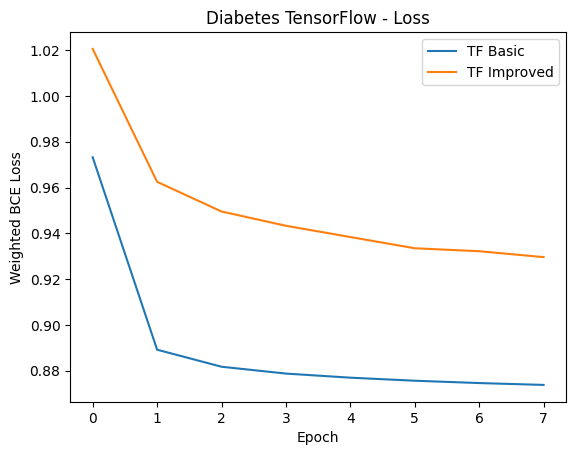

In [12]:
plt.plot(tf_basic_hist.history["loss"],label="TF Basic")
plt.plot(tf_imp_hist.history["loss"],label="TF Improved")
plt.xlabel("Epoch");plt.ylabel("Weighted BCE Loss")
plt.title("Diabetes TensorFlow - Loss")
plt.legend();plt.show()

## 5. Bảng so sánh

In [13]:
diabetes_results=pd.DataFrame([
    ["NumPy From Scratch","Basic",scratch_acc,scratch_p,scratch_r,scratch_f1],
    ["PyTorch","Basic",pt_basic_acc,pt_basic_p,pt_basic_r,pt_basic_f1],
    ["PyTorch","Improved",pt_imp_acc,pt_imp_p,pt_imp_r,pt_imp_f1],
    ["TensorFlow","Basic",tf_basic_acc,tf_basic_p,tf_basic_r,tf_basic_f1],
    ["TensorFlow","Improved",tf_imp_acc,tf_imp_p,tf_imp_r,tf_imp_f1],
],columns=["Implementation","Model","Accuracy","Precision","Recall","F1"])

display(diabetes_results)
diabetes_results.to_csv(RESULT_DIR/"diabetes_comparison_fixed.csv",index=False)

,Implementation,Model,Accuracy,Precision,Recall,F1
0,NumPy From Scratch,Basic,0.732576,0.308233,0.738860,0.434996
1,PyTorch,Basic,0.709575,0.297987,0.799830,0.434205
2,PyTorch,Improved,0.752956,0.321929,0.698826,0.440796
3,TensorFlow,Basic,0.734666,0.313995,0.763333,0.444958
4,TensorFlow,Improved,0.753922,0.321701,0.691187,0.439053


### Nhận xét khi báo cáo
Dataset lệch lớp mạnh nên **không được chỉ nhìn Accuracy**. Hãy ưu tiên đọc thêm Precision, Recall và F1. Weighted loss được dùng để phạt lỗi ở lớp dương mạnh hơn, giúp hạn chế hiện tượng model chỉ dự đoán lớp 0.